# EDA 06 - Road Closures + Timetable (Merged)

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/darwin_timetable_clean.parquet`  
**Output**: `data/processed/road_timetable_dataset.parquet` - consumed by `rail_delay_prediction.ipynb` for forward prediction

This notebook performs EDA on the road closure + Darwin timetable merged dataset. Unlike the road + train moments dataset (EDA 05), this dataset contains **no actual timestamps** - it is the prediction dataset where planned service times are known but outcomes have not yet been observed. The goal is to understand the scheduled services that fall within the road closure impact zone before the model generates delay forecasts.

---
**Sections**
1. Rebuild the road + timetable dataset from processed parquets  
2. Dataset overview and shape  
3. Coverage comparison: timetable vs analytical (train moments)  
4. Predictor distributions (distance, time since closure)  
5. Categorical distributions (closure type, event type, TOC)  
6. Bivariate relationships (distance x time, correlation matrix)  
7. Scheduled service frequency by hour  
8. Spatial patterns (stations, closure impact on timetable)  
9. Planned time diff distribution within closure window  
10. Save output  


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_06", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Rebuild Road + Timetable Dataset

Read the processed parquets saved by EDA 02 (road closures) and EDA 04 (Darwin timetable), then re-run the spatial join and temporal filter using the timetable schedule instead of train moments. This mirrors the pipeline in the main analysis notebook.

In [2]:
from src.geo import find_nearby_stations
from src.features import (
    reshape_timetable_to_schedule,
    merge_schedule_with_closures,
    filter_within_time_window,
)

ROAD_PATH      = "./data/processed/road_closures_clean.parquet"
TIMETABLE_PATH = "./data/processed/darwin_timetable_clean.parquet"
stations_reference_path = "./data/processed/stations_reference.parquet"

if not os.path.exists(ROAD_PATH):
    raise FileNotFoundError("Run EDA 02 first to generate road_closures_clean.parquet")
if not os.path.exists(TIMETABLE_PATH):
    raise FileNotFoundError("Run EDA 04 first to generate darwin_timetable_clean.parquet")

road_df      = pd.read_parquet(ROAD_PATH)
timetable_df = pd.read_parquet(TIMETABLE_PATH)
stations_ref_df = pd.read_parquet(stations_reference_path)

print(f"Road closures:    {len(road_df):,} rows")
print(f"Timetable stops:  {len(timetable_df):,} rows")

Road closures:    1,557 rows
Timetable stops:  18,215,122 rows


In [3]:
# Spatial join: match each closure to stations within 10-25 km
expanded_road_df = find_nearby_stations(road_df,stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")

Closure-station pairs: 99,298


In [7]:
schedule_df = reshape_timetable_to_schedule(timetable_df, stations_ref_df)
print(f"Schedule rows (after reshape): {len(schedule_df):,}")
schedule_df.head()

Schedule rows (after reshape): 18,215,122


,ssd,tpl,station_code,stanox,station_name,timetable_train_id,planned_timestamp,event_type
0,2026-04-10,WATRLMN,NaN,NaN,NaN,2S69,2026-04-10 21:22:00,DEPARTURE
1,2026-04-10,WATRLWC,NaN,NaN,NaN,2S69,2026-04-10 21:23:30,PASS
2,2026-04-10,VAUXHLM,NaN,NaN,NaN,2S69,2026-04-10 21:25:30,ARRIVAL
3,2026-04-10,NINELMJ,NaN,NaN,NaN,2S69,2026-04-10 21:28:00,PASS
4,2026-04-10,QTRDBAT,QRB,87216,Queenstown Road (Battersea),2S69,2026-04-10 21:29:00,ARRIVAL


In [8]:
# Merge closures with schedule on stanox
merged_schedule = merge_schedule_with_closures(expanded_road_df, schedule_df)
print(f"After merge: {len(merged_schedule):,} rows")

merged_schedule["closure_start_time"] = pd.to_datetime(merged_schedule["closure_start_time"])
merged_schedule["planned_timestamp"] = pd.to_datetime(merged_schedule["planned_timestamp"])
merged_schedule = merged_schedule.dropna(subset=["planned_timestamp"])
merged_schedule["planned_time_diff"] = ((merged_schedule["planned_timestamp"] - merged_schedule["closure_start_time"]).dt.total_seconds() / 60)

# Select final columns - no actual_timestamp here (timetable only)
keep_cols = [
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "validity_status", "cause_type",
    "distance_in_km", "station_name", "stanox", "tpl",
    "closure_start_time", "planned_timestamp",
    "planned_time_diff", "event_type",
]
merged_schedule = merged_schedule[[c for c in keep_cols if c in merged_schedule.columns]].copy()
merged_schedule["planned_timestamp"] = pd.to_datetime(merged_schedule["planned_timestamp"])

# Interaction feature
merged_schedule["distance_time_interaction"] = (
    merged_schedule["distance_in_km"] * merged_schedule["planned_time_diff"]
)


print(f"\nFinal road + timetable dataset: {len(merged_schedule):,} rows")
merged_schedule.head()

After merge: 26,085,962 rows

Final road + timetable dataset: 25,845,722 rows


,closure_id,closure_type,validity_status,cause_type,distance_in_km,station_name,stanox,tpl,closure_start_time,planned_timestamp,planned_time_diff,event_type,distance_time_interaction
0,481398,planned,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,ARRIVAL,1293.719539
1,481398,planned,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 12:24:00,-396.0,PASS,-8538.548960
2,481398,planned,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 11:02:30,-477.5,PASS,-10295.851334
3,481398,planned,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 12:03:00,-417.0,ARRIVAL,-8991.350799
4,481398,planned,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 15:02:30,-237.5,PASS,-5120.973177


## 2. Dataset Overview

In [9]:
merged_schedule.info()

<class 'pandas.DataFrame'>
Index: 25845722 entries, 0 to 26085961
Data columns (total 13 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   closure_id                 str           
 1   closure_type               str           
 2   validity_status            str           
 3   cause_type                 str           
 4   distance_in_km             float64       
 5   station_name               str           
 6   stanox                     str           
 7   tpl                        str           
 8   closure_start_time         datetime64[us]
 9   planned_timestamp          datetime64[us]
 10  planned_time_diff          float64       
 11  event_type                 str           
 12  distance_time_interaction  float64       
dtypes: datetime64[us](2), float64(3), str(8)
memory usage: 5.0 GB


In [10]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:              {len(merged_schedule):,}")
print(f"Unique stations:         {merged_schedule['station_name'].nunique():,}")
print(f"Unique closures:         {merged_schedule['closure_id'].nunique():,}")
print(f"Date range (planned):    {merged_schedule['planned_timestamp'].min()} - {merged_schedule['planned_timestamp'].max()}")
print()
print("By closure type:")
print(merged_schedule["closure_type"].value_counts().to_string())
print()
print("By event type:")
print(merged_schedule["event_type"].value_counts().to_string())

DATASET SUMMARY
Total rows:              25,845,722
Unique stations:         1,639
Unique closures:         1,116
Date range (planned):    2026-04-09 00:01:00 - 2026-04-28 23:59:30

By closure type:
closure_type
unplanned    24609823
planned       1235899

By event type:
event_type
ARRIVAL      19586030
PASS          4830845
DEPARTURE     1428847


## 3. Coverage Comparison: Timetable vs Train Moments

This section compares how many rows each data source contributes after the same spatial and temporal filtering. The difference reveals how many scheduled services lack corresponding train movement records, these are the observations that the model predicts for but cannot validate directly.

In [11]:
MOMENTS_PATH = "./data/processed/road_train_moments_dataset.parquet"

if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)
    print(f"{'Source':<30} {'Rows':>10} {'Unique stations':>17} {'Unique closures':>17}")
    print("-" * 80)
    print(f"{'Road + Train Moments (EDA 05)':<30} {len(moments_df):>10,} {moments_df['station_name'].nunique():>17,} {moments_df['closure_id'].nunique():>17,}")
    print(f"{'Road + Timetable (this NB)':<30} {len(merged_schedule):>10,} {merged_schedule['station_name'].nunique():>17,} {merged_schedule['closure_id'].nunique():>17,}")
    ratio = len(merged_schedule) / len(moments_df)
    print(f"\nTimetable is {ratio:.1f}x larger than train moments dataset")
else:
    print("analytical_dataset.parquet not found - run EDA 05 first for comparison")

Source                               Rows   Unique stations   Unique closures
--------------------------------------------------------------------------------
Road + Train Moments (EDA 05)     559,307             1,567             1,056
Road + Timetable (this NB)     25,845,722             1,639             1,116

Timetable is 46.2x larger than train moments dataset


In [12]:
if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)

    # Station overlap
    t_stations = set(merged_schedule["station_name"].dropna())
    m_stations = set(moments_df["station_name"].dropna())
    overlap    = t_stations & m_stations
    timetable_only = t_stations - m_stations
    moments_only   = m_stations - t_stations

    print(f"Stations in timetable only:    {len(timetable_only):,}")
    print(f"Stations in both datasets:     {len(overlap):,}")
    print(f"Stations in train moments only:{len(moments_only):,}")

    # Closure overlap
    t_closures = set(merged_schedule["closure_id"].dropna())
    m_closures = set(moments_df["closure_id"].dropna())
    print(f"\nClosures in timetable only:    {len(t_closures - m_closures):,}")
    print(f"Closures in both datasets:     {len(t_closures & m_closures):,}")
    print(f"Closures in moments only:      {len(m_closures - t_closures):,}")

Stations in timetable only:    86
Stations in both datasets:     1,553
Stations in train moments only:14

Closures in timetable only:    60
Closures in both datasets:     1,056
Closures in moments only:      0


## 4. Predictor Distributions

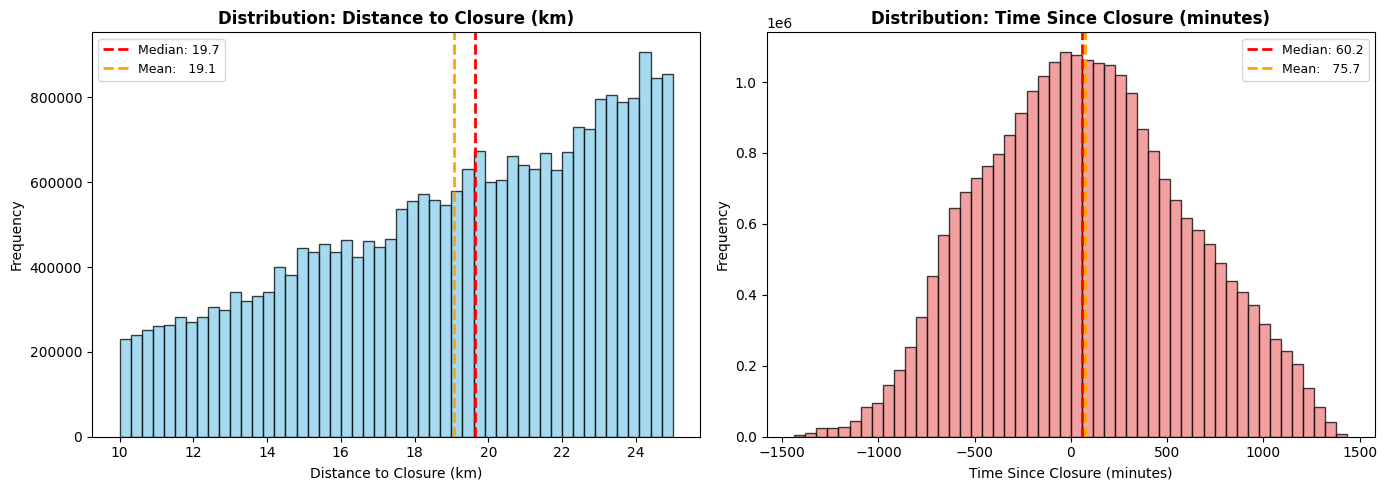


distance_in_km: mean=19.06, median=19.65, std=4.09, min=10.00, max=25.00

planned_time_diff: mean=75.73, median=60.23, std=521.46, min=-1437.52, max=1436.65


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "distance_in_km",   "skyblue",    "Distance to Closure (km)"),
    (axes[1], "planned_time_diff","lightcoral", "Time Since Closure (minutes)")
]:
    s = merged_schedule[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red",    linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(),   color="orange", linestyle="--", lw=2, label=f"Mean:   {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution: {label}", fontweight="bold")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_06/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

for col in ["distance_in_km", "planned_time_diff"]:
    s = merged_schedule[col]
    print(f"\n{col}: mean={s.mean():.2f}, median={s.median():.2f}, "
          f"std={s.std():.2f}, min={s.min():.2f}, max={s.max():.2f}")

## 5. Categorical Distributions

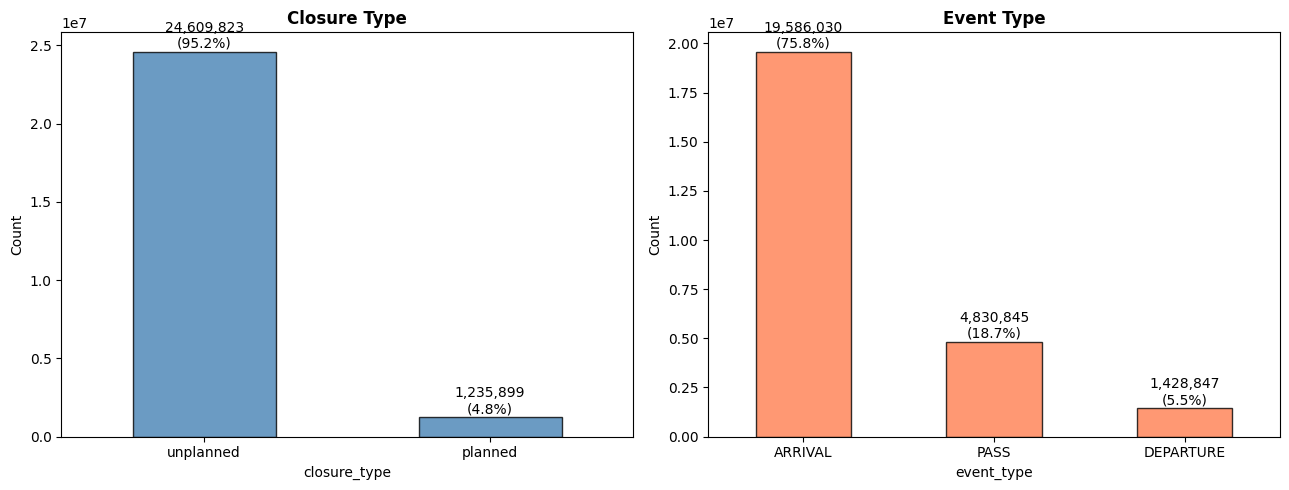

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = merged_schedule["closure_type"].value_counts()
ct.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + max(ct)*0.01, f"{v:,}\n({v/len(merged_schedule)*100:.1f}%)",
                 ha="center", fontsize=10)

et = merged_schedule["event_type"].value_counts()
et.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Event Type", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[1].text(i, v + max(et)*0.01, f"{v:,}\n({v/len(merged_schedule)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_06/categorical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
# Closure type x event type cross-tabulation
ct_et = pd.crosstab(merged_schedule["closure_type"], merged_schedule["event_type"],
                    margins=True, margins_name="Total")
print("Closure type x Event type:")
print(ct_et.to_string())

Closure type x Event type:
event_type     ARRIVAL  DEPARTURE     PASS     Total
closure_type                                        
planned         943311      80369   212219   1235899
unplanned     18642719    1348478  4618626  24609823
Total         19586030    1428847  4830845  25845722


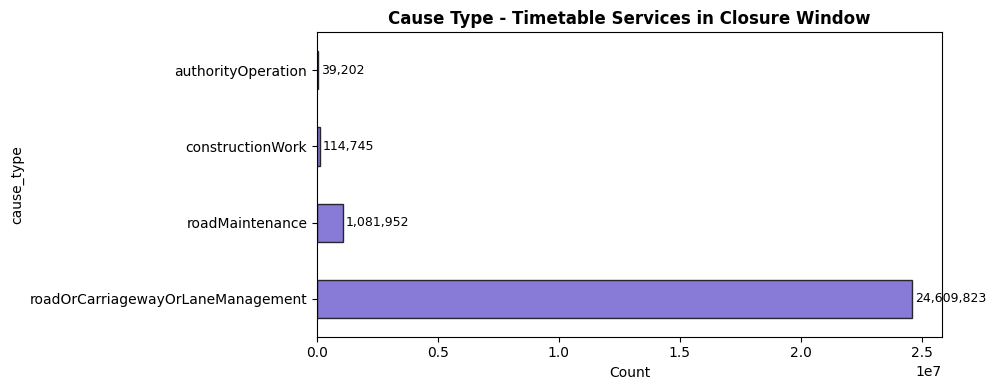

In [16]:
# Cause type distribution
if "cause_type" in merged_schedule.columns:
    cause = merged_schedule["cause_type"].value_counts()
    plt.figure(figsize=(10, 4))
    cause.plot(kind="barh", color="slateblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Count")
    plt.title("Cause Type - Timetable Services in Closure Window", fontweight="bold")
    for i, v in enumerate(cause.values):
        plt.text(v + max(cause)*0.005, i, f"{v:,}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_06/cause_type.png", dpi=200, bbox_inches="tight")
    plt.show()

## 6. Bivariate Relationships

There is no delay column in this dataset (it is the prediction dataset). Instead, bivariate analysis examines how predictors relate to each other, and how service density varies across the spatial-temporal space.

C:\Users\nehav\AppData\Local\Temp\ipykernel_4324\2660218917.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


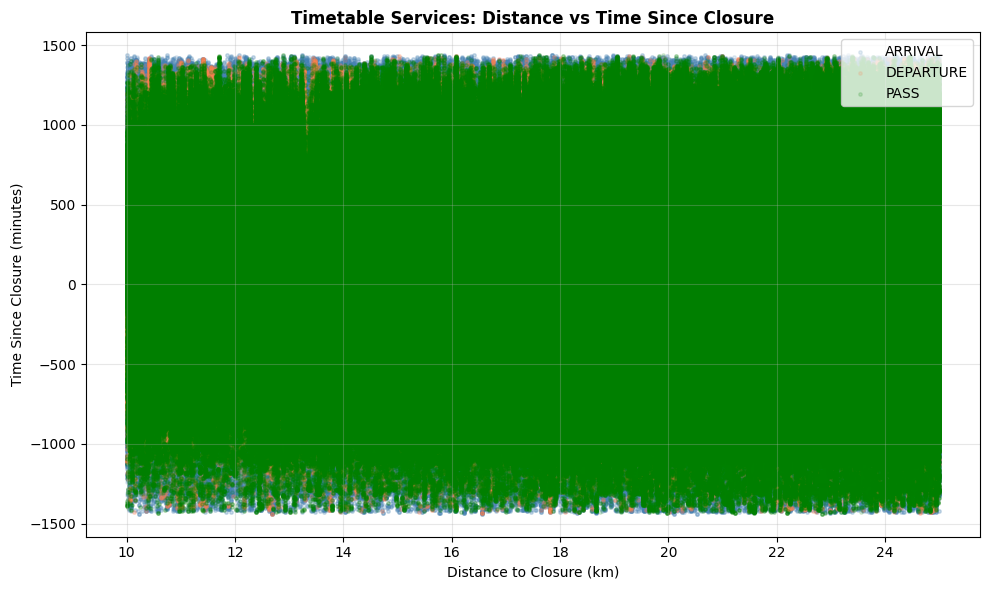

In [17]:
# Scatter: distance vs planned_time_diff coloured by event type
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"ARRIVAL": "steelblue", "DEPARTURE": "coral", "PASS": "green"}
for etype, grp in merged_schedule.groupby("event_type"):
    ax.scatter(grp["distance_in_km"], grp["planned_time_diff"],
               alpha=0.15, s=6, label=etype, color=colors.get(etype, "grey"))
ax.set_xlabel("Distance to Closure (km)")
ax.set_ylabel("Time Since Closure (minutes)")
ax.set_title("Timetable Services: Distance vs Time Since Closure", fontweight="bold")
ax.legend(title="Event Type", markerscale=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.legend(loc="upper right")
plt.savefig("figures/eda_06/scatter_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

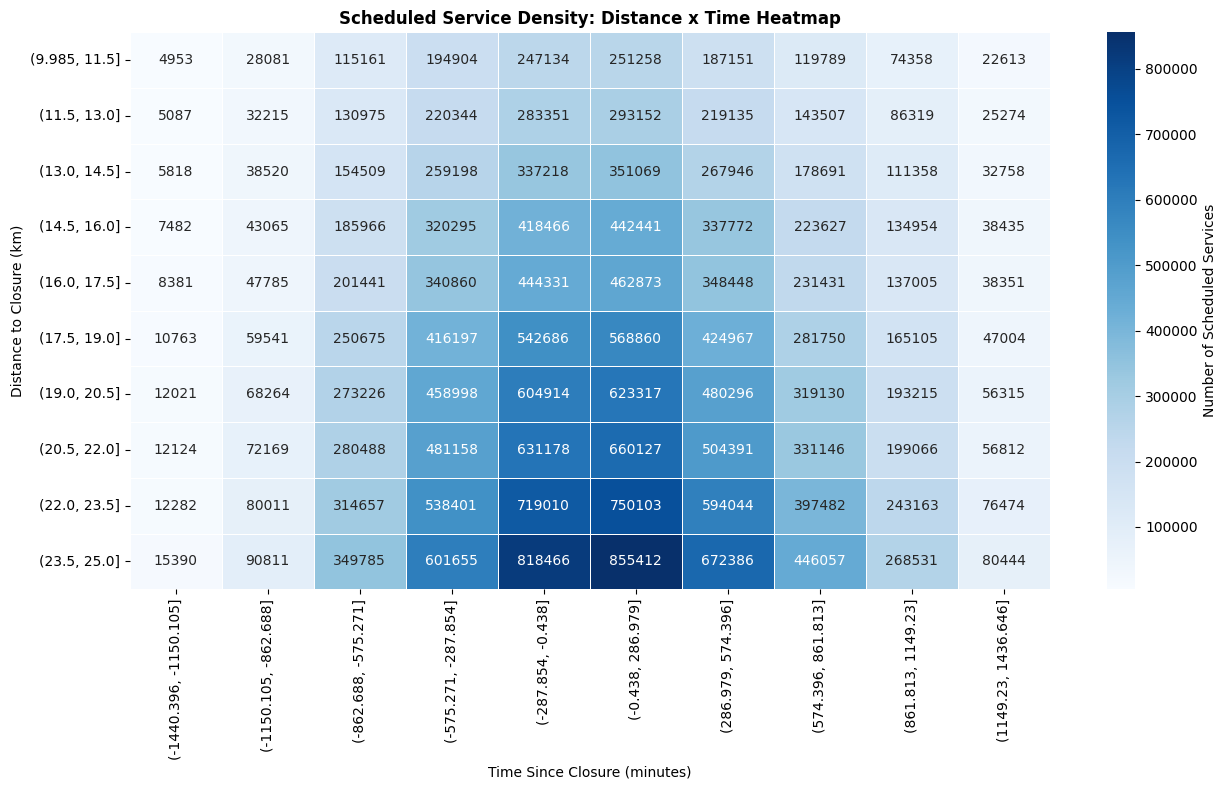

In [18]:
# Service density heatmap: count of scheduled services per distance x time bin
# %xmode Minimal

hm = merged_schedule.copy()
hm["dist_bin"] = pd.cut(hm["distance_in_km"],   bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="planned_timestamp", index="dist_bin",
                       columns="time_bin", aggfunc="count")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "Number of Scheduled Services"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Scheduled Service Density: Distance x Time Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/heatmap_service_density.png", dpi=200, bbox_inches="tight")
plt.show()

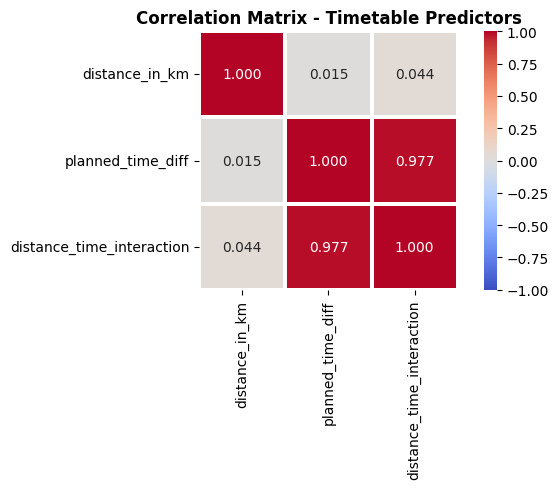

                           distance_in_km  planned_time_diff  distance_time_interaction
distance_in_km                   1.000000           0.014656                   0.043962
planned_time_diff                0.014656           1.000000                   0.977347
distance_time_interaction        0.043962           0.977347                   1.000000


In [19]:
# Correlation matrix of numeric predictors
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction"]
corr_matrix  = merged_schedule[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix - Timetable Predictors", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print(corr_matrix.to_string())

## 7. Scheduled Service Frequency by Hour

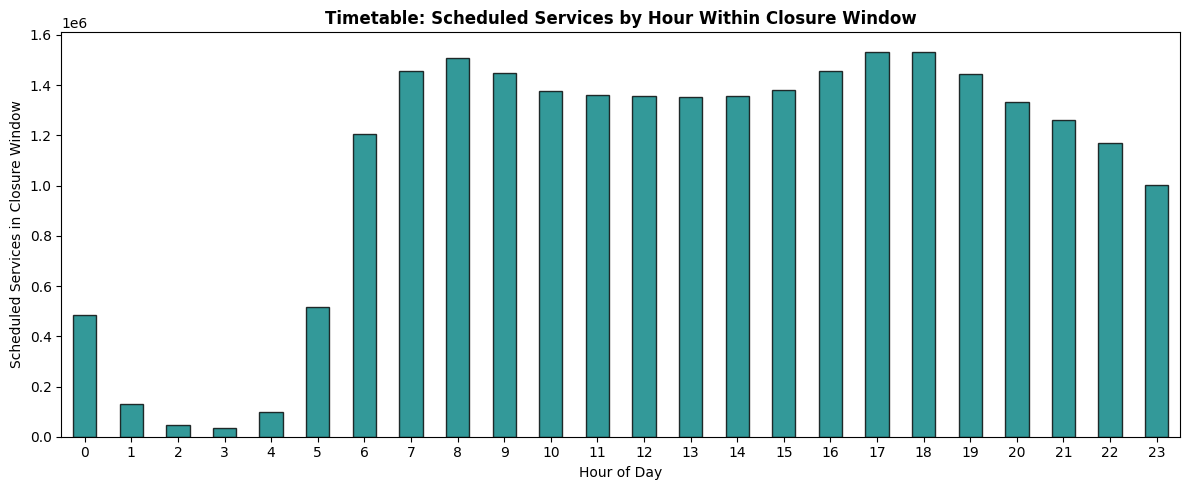

Scheduled services by hour:
hour
0      485174
1      128691
2       44898
3       34950
4       97401
5      516213
6     1204656
7     1456913
8     1507895
9     1449069
10    1377741
11    1360549
12    1354968
13    1354578
14    1356841
15    1382036
16    1455273
17    1533822
18    1530910
19    1442874
20    1334750
21    1261376
22    1170582
23    1003562


In [20]:
merged_schedule["hour"] = merged_schedule["planned_timestamp"].dt.hour
hour_counts = merged_schedule["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
hour_counts.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Scheduled Services in Closure Window")
plt.title("Timetable: Scheduled Services by Hour Within Closure Window", fontweight="bold")
plt.xticks(range(len(hour_counts)), hour_counts.index, rotation=0)
plt.tight_layout()
plt.savefig("figures/eda_06/scheduled_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

print("Scheduled services by hour:")
print(hour_counts.to_string())

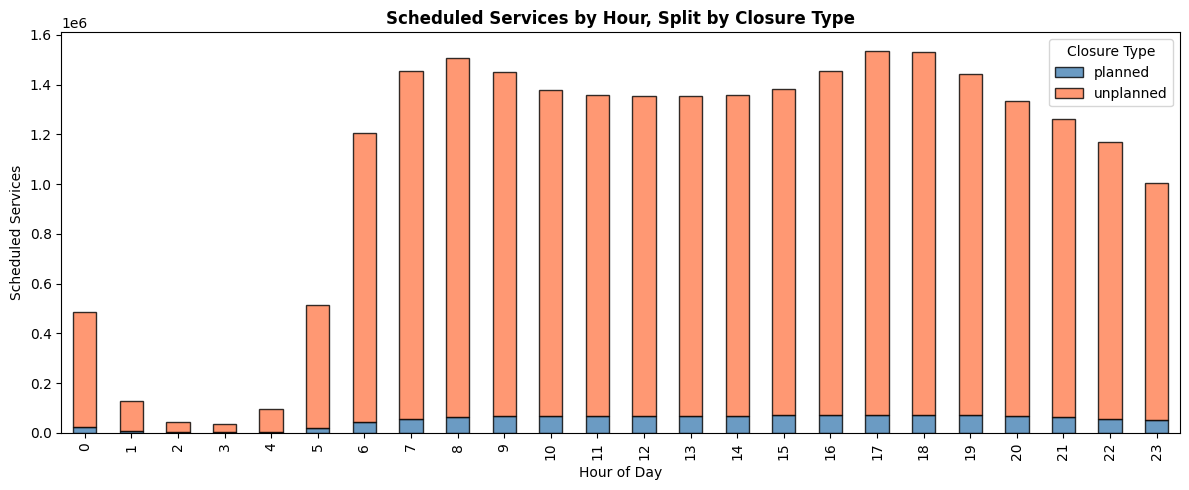

In [21]:
# Hour x closure type breakdown
hour_ct = merged_schedule.groupby(["hour", "closure_type"]).size().unstack(fill_value=0)
hour_ct.plot(kind="bar", stacked=True, figsize=(12, 5),
             color=["steelblue", "coral"], edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Scheduled Services")
plt.title("Scheduled Services by Hour, Split by Closure Type", fontweight="bold")
plt.legend(title="Closure Type")
plt.tight_layout()
plt.savefig("figures/eda_06/scheduled_by_hour_closure_type.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Spatial Patterns

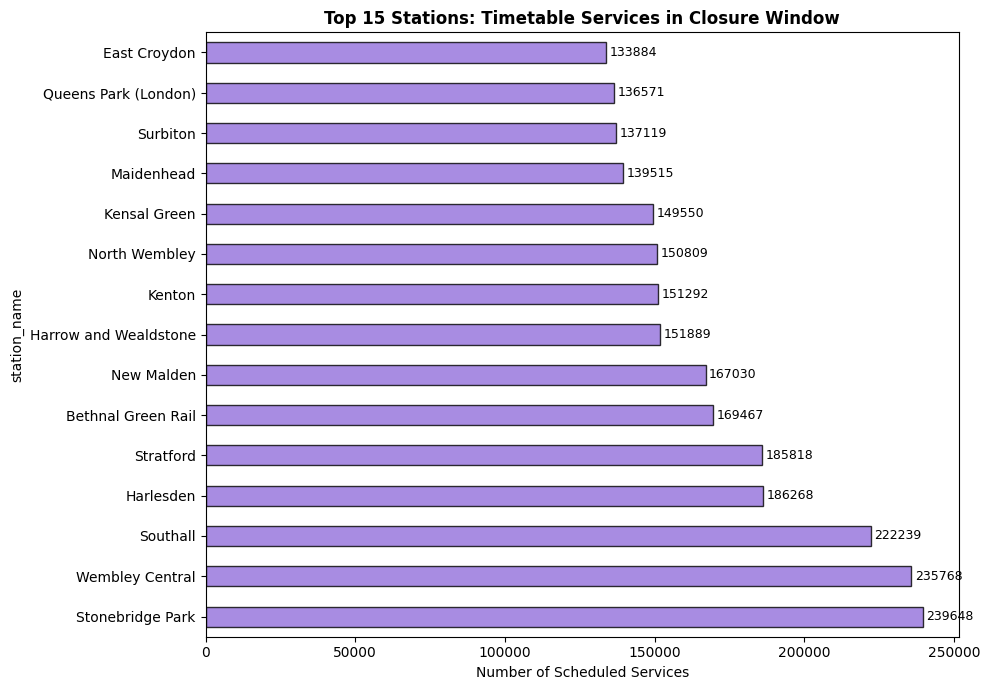

Top 15 stations: 2,556,867 rows (9.9% of total)


In [22]:
top_stations = merged_schedule["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Scheduled Services")
plt.title("Top 15 Stations: Timetable Services in Closure Window", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + max(top_stations)*0.005, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_06/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(merged_schedule)*100:.1f}% of total)")

In [23]:
# Compare top stations: timetable vs train moments
if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)
    top_t = merged_schedule["station_name"].value_counts().head(15).rename("timetable")
    top_m = moments_df["station_name"].value_counts().reindex(top_t.index).rename("moments")
    comparison = pd.concat([top_t, top_m], axis=1).fillna(0).astype(int)
    print("Top 15 stations: timetable vs train moments row counts")
    print(comparison.to_string())

Top 15 stations: timetable vs train moments row counts
                       timetable  moments
station_name                             
Stonebridge Park          239648     1913
Wembley Central           235768     3661
Southall                  222239     4837
Harlesden                 186268     2171
Stratford                 185818     3508
Bethnal Green Rail        169467     3027
New Malden                167030     3949
Harrow and Wealdstone     151889     3746
Kenton                    151292     1733
North Wembley             150809     2066
Kensal Green              149550     1862
Maidenhead                139515     2861
Surbiton                  137119     3082
Queens Park (London)      136571     1707
East Croydon              133884     2957


Unique closures affecting timetable: 1,116
Mean services per closure:           23159.2
Median services per closure:         12706.5
Max services per closure:            157,907


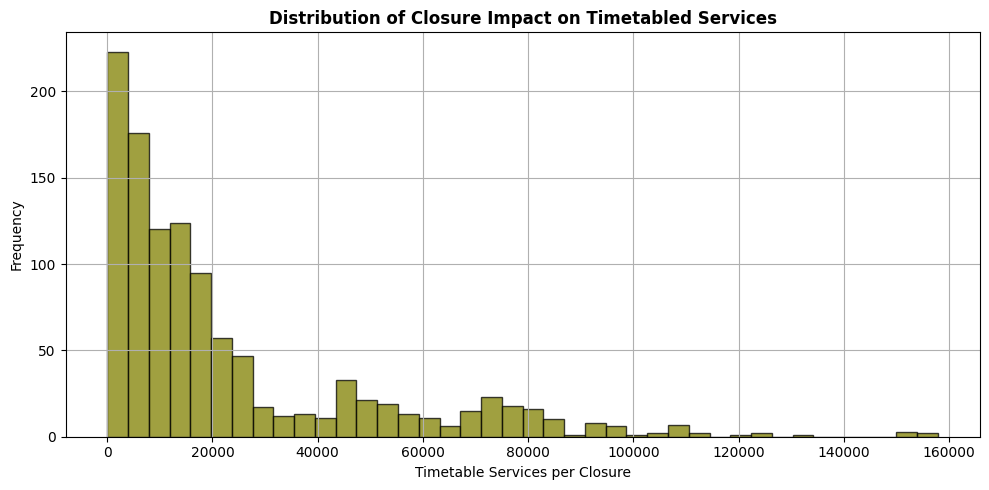

In [24]:
# Closure impact: how many timetable services does each closure affect?
closure_impact = merged_schedule.groupby("closure_id").size().sort_values(ascending=False)
print(f"Unique closures affecting timetable: {len(closure_impact):,}")
print(f"Mean services per closure:           {closure_impact.mean():.1f}")
print(f"Median services per closure:         {closure_impact.median():.1f}")
print(f"Max services per closure:            {closure_impact.max():,}")

plt.figure(figsize=(10, 5))
closure_impact.hist(bins=40, edgecolor="black", alpha=0.75, color="olive")
plt.xlabel("Timetable Services per Closure")
plt.ylabel("Frequency")
plt.title("Distribution of Closure Impact on Timetabled Services", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/closure_impact.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Planned Time Diff Distribution Within Closure Window

Understanding how timetable services are distributed across the 0-60 minute window informs whether the temporal filter captures a representative slice of scheduled operations or is dominated by services at particular intervals.

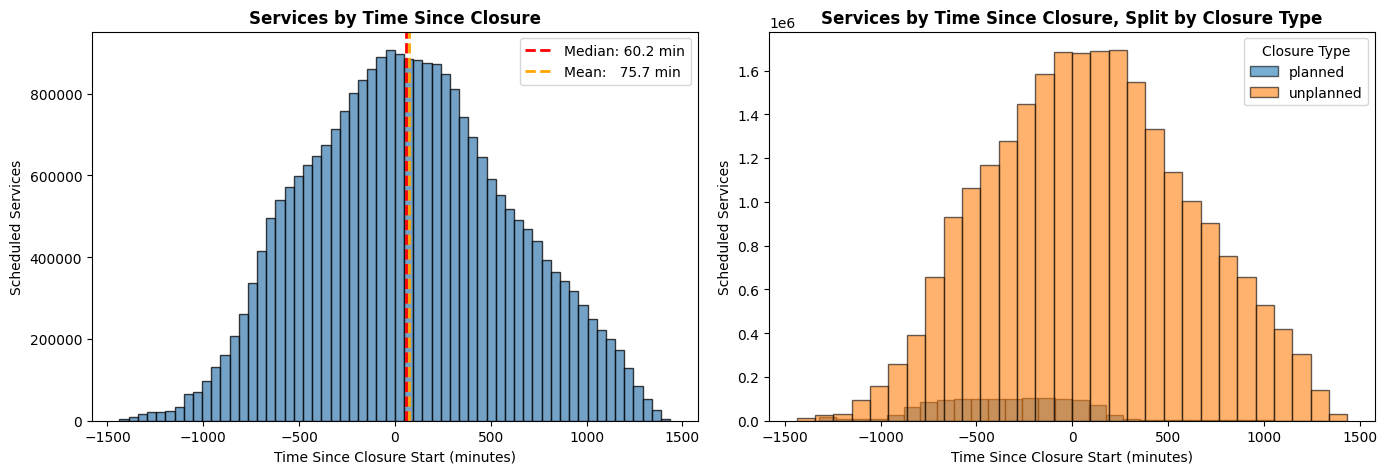

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
s = merged_schedule["planned_time_diff"]
axes[0].hist(s, bins=60, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(s.median(), color="red",    linestyle="--", lw=2, label=f"Median: {s.median():.1f} min")
axes[0].axvline(s.mean(),   color="orange", linestyle="--", lw=2, label=f"Mean:   {s.mean():.1f} min")
axes[0].set_xlabel("Time Since Closure Start (minutes)")
axes[0].set_ylabel("Scheduled Services")
axes[0].set_title("Services by Time Since Closure", fontweight="bold")
axes[0].legend()

# By closure type
for ctype, grp in merged_schedule.groupby("closure_type"):
    axes[1].hist(grp["planned_time_diff"], bins=30, alpha=0.6,
                 edgecolor="black", label=ctype)
axes[1].set_xlabel("Time Since Closure Start (minutes)")
axes[1].set_ylabel("Scheduled Services")
axes[1].set_title("Services by Time Since Closure, Split by Closure Type", fontweight="bold")
axes[1].legend(title="Closure Type")

plt.tight_layout()
plt.savefig("figures/eda_06/planned_time_diff_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [26]:
# 10-minute bucket analysis
merged_schedule["time_bucket"] = pd.cut(
    merged_schedule["planned_time_diff"],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
)
bucket_ct = merged_schedule.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)
print("Scheduled services by 10-minute bucket and closure type:")
print(bucket_ct.to_string())
bucket_ct["Total"] = bucket_ct.sum(axis=1)
print(f"\nProportion per bucket:\n{(bucket_ct['Total'] / bucket_ct['Total'].sum() * 100).round(1).to_string()}")

Scheduled services by 10-minute bucket and closure type:
closure_type  planned  unplanned
time_bucket                     
0-10            11327     178058
10-20           11030     177171
20-30           10886     175176
30-40           10576     175323
40-50           10946     175550
50-60           10509     174133

Proportion per bucket:
time_bucket
0-10     16.9
10-20    16.8
20-30    16.6
30-40    16.6
40-50    16.6
50-60    16.5


## 10. Save Output

In [27]:
merged_schedule.to_parquet("./data/processed/road_timetable_dataset.parquet", index=False)
print(f"Saved road + timetable dataset: {len(merged_schedule):,} rows")
print("Path: data/processed/road_timetable_dataset.parquet")
print()
print("Column summary:")
merged_schedule.info()

Saved road + timetable dataset: 25,845,722 rows
Path: data/processed/road_timetable_dataset.parquet

Column summary:
<class 'pandas.DataFrame'>
Index: 25845722 entries, 0 to 26085961
Data columns (total 15 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   closure_id                 str           
 1   closure_type               str           
 2   validity_status            str           
 3   cause_type                 str           
 4   distance_in_km             float64       
 5   station_name               str           
 6   stanox                     str           
 7   tpl                        str           
 8   closure_start_time         datetime64[us]
 9   planned_timestamp          datetime64[us]
 10  planned_time_diff          float64       
 11  event_type                 str           
 12  distance_time_interaction  float64       
 13  hour                       int32         
 14  time_bucket                